<a href="https://colab.research.google.com/github/anaacevedo1980/DataScienceI_CarreraData/blob/main/Primer_Entrega_Data_Sciencie_II_Acevedo_Ana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modelado Predictivo de Costos en Logística: Enfoque de Machine Learning**

El presente proyecto tiene como objetivo analizar y modelar el comportamiento logístico de un servicio de encomienda a partir de un conjunto de datos que documenta el flujo completo de envíos de extremo a extremo. Este dataset incluye información detallada sobre remitente y destinatario, peso real y volumétrico, modalidad de entrega (Express, Surface, Air Cargo), cargos aplicados (tarifa base, recargos por servicios adicionales, peso facturable) y estado operativo del envío.

A través de técnicas de análisis exploratorio, detección de outliers y visualización multivariada, se busca comprender los patrones que rigen la estructura de costos y el desempeño operativo del sistema. Posteriormente, se implementarán modelos predictivos que permitan estimar el monto total facturado en función de variables logísticas clave, con el fin de optimizar la toma de decisiones en procesos de tarificación, planificación y eficiencia operativa.

Para guiar el análisis, se plantean las siguientes hipótesis:

1) **Influencia del peso facturable**

H₀: El peso facturable (Chargeable Wt) no tiene un efecto significativo sobre el monto total (Total Amount).

H₁: El peso facturable sí tiene un efecto significativo sobre el monto total.

2) **Diferencias por modo de envío**

H₀: El modo de envío (Mode) no influye en el monto total facturado.

H₁: El modo de envío sí influye en el monto total facturado.

3) **Cargos adicionales**

H₀: Los cargos por servicios adicionales (VAS Charges) no afectan significativamente el monto total.

H₁: Los cargos por servicios adicionales sí afectan significativamente el monto total.

4) **Modelo multivariable**

H₀: Ninguna de las variables independientes (peso, piezas, modo, recargos) tiene efecto significativo sobre el monto total.

H₁: Al menos una de las variables independientes tiene efecto significativo sobre el monto total.

Este enfoque permitirá no solo validar estadísticamente el impacto de cada variable, sino también construir modelos robustos de predicción que puedan ser aplicados en entornos reales de logística y distribución.

## Descripción de columnas

   **Origin:** La ciudad desde la que se reservó originalmente o despachó la parcela.

   **Destination:** La ciudad donde se pretende entregar la parcela.

   **Pouch No:** Un identificador interno único (a menudo UUID) utilizado para agrupar envíos en logística.

   **Date:** La fecha en que se reservaba el envío, representado en formato número serie de Excel.

   **Sender's Name**: Nombre completo de la persona o empresa que envía el paquete.

   **Sender Phone:** Número de contacto móvil o fijo del remitente.

  **Sender Address:** Dirección completa del remitente para la recogida y los registros.

  **Sender City:** La ciudad del remitente puede duplicar el campo "Origen".

  **Sender State:** El estado indio en el que se encuentra el remitente.

  **Sender Pincode:** El código postal de 6 dígitos (ZIP) de la ubicación del remitente.

  **Sender GSTIN:** GST Número de identificación del remitente (si procede en los envíos comerciales).

  **Total Pieces:** Número de paquetes físicos individuales incluidos en el envío.

  **Wt Actual:** El peso físico real (en kilogramos) de los paquetes.

  **Volumetric Wt:** El peso calculado sobre la base de las dimensiones de volumen, utilizado para los fines de facturación.

  **Chargeable Wt:** El peso utilizado para la facturación -normalmente el mayor de peso real o volumétrico.

  **Paperwork:** Indica si se presentó papeleo junto con el paquete (Sí/No).

  **Sender Signature:** Denota si el remitente firmó la documentación de despacho (Sí/No).

  **Sender Date:** La fecha en que el remitente completó los documentos de entrega o firmados, en formato serie Excel.

  **Recipient Name:** El nombre completo de la persona u organización pretendía recibir el paquete.

  **Recipient Phone**: El número de contacto del destinatario previsto.

  **Recipient Address:** La dirección de entrega completa donde debe enviarse el paquete.

  **Recipient City:** La ciudad del destinatario puede duplicar el campo "Destino".

  **Receiver State:** El estado indio donde reside el receptor.

  **Receiver Pincode:** El código postal o ZIP de 6 dígitos de la dirección de entrega.

  **Description:** Una breve descripción textual del contenido del paquete (por ejemplo, documentos, elementos).

  **Value Added Services:** Servicios opcionales añadidos al envío, como manipulación frágil, entrega exprés, seguros, etc.

  **Consignment No:** El número de seguimiento oficial de DTDC asignado al envío.

  **Expiry Date:** la última fecha válida para la entrega, después de la cual el envío puede expirar o ser devuelto. Almacenado como número de serie de Excel.

  **Booking Code**: El código único que identifica la sucursal de DTDC o contador de reservas.

  **Recipient GSTIN:** Número de identificación GST del destinatario (si procede).

  **Receiver Name:** Un campo alternativo o duplicado para el nombre del destinatario.

  **Relationship:** Describe la relación del receptor con el destinatario original (por ejemplo, uno mismo, Personal, Familia).

  **Company Stamp:** Indica si se utilizó un sello de la empresa durante el recibo (Sí/No).

  **Receiver Signaturer:** Indica si el destinatario firmó la confirmación de entrega (Sí/No).

  **Receive Date:** La fecha en que se recibió el paquete, en formato serie de Excel.

  **Tariff:** La carga de entrega de la base en rupias indias.

  **VAS Charges:** Cargos adicionales por cualquier servicio de valor agregado aplicado al envío.

  **Total Amount:** El importe total facturado para el envío, incluyendo tarifas y complementos.

  **Mode:** El modo de envío elegido . Superficie, aire o Express.

  **Risk Surcharge:** Denota quién asume la responsabilidad de riesgo - el propietario (enferr) o Carrier (DTDC).

  **Mode of Payment:** El método de pago utilizado en la reserva, como Efectivo, Tarjeta, UPI, Wallet, etc.
    
  **Nature of Consignment:** Indica el tipo de paquete de paquetería "Dox" para documentos o "No-Dox" para mercancías/mercancías.

In [123]:
# IMPORTACIÓN DE LIBRERÍAS COMPLETAS

# --- LIBRERÍAS DE DATOS ---
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# --- VISUALIZACIÓN ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- ANÁLISIS ESTADÍSTICO ---
from scipy import stats
from scipy.stats import normaltest, shapiro, kstest, chi2_contingency
from scipy.stats import pearsonr, spearmanr

# --- MACHINE LEARNING ---
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- API Y REQUESTS ---
import requests
from io import StringIO
import json
import time

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from geopy.distance import geodesic
from tqdm import tqdm

print(" Librerías importadas exitosamente")

 Librerías importadas exitosamente


In [124]:
# Configuración de visualización
#  Azul corporativo más fuerte (gama consistente y muy visible)
palette_azules_fuertes = [
    "#1B4F72",  # Azul profundo
    "#21618C",
    "#2874A6",
    "#2E86C1",
    "#3498DB",
    "#5DADE2",
    "#85C1E9",
    "#AED6F1"   # Azul claro pero no lavado
]
sns.set_palette(palette_azules_fuertes)

#  Ajustes globales de estilo
plt.style.use("seaborn-v0_8-darkgrid")
# Pandas display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

# plt.rcParams["patch.alpha"] = 0.9      # barras más sólidas  <-- This line is removed
plt.rcParams["lines.linewidth"] = 2.5  # líneas más definidas
plt.rcParams["figure.figsize"] = (12, 6)        # tamaño por defecto
plt.rcParams["axes.titlesize"] = 14            # tamaño título
plt.rcParams["axes.labelsize"] = 12            # etiquetas ejes
plt.rcParams["axes.titleweight"] = "bold"      # negrita título
plt.rcParams["axes.labelweight"] = "bold"      # negrita etiquetas
plt.rcParams["lines.linewidth"] = 2            # grosor de líneas

In [125]:
warnings.filterwarnings('ignore') # Ignora advertencias, lo cual es util para presentaciones

In [126]:
import requests

url = "https://raw.githubusercontent.com/anaacevedo1980/ProyectoDataScienceI/refs/heads/main/Dataset_Generator_for_DTDC.csv"

response = requests.get(url)  # Hace una solicitud GET para obtener el contenido del archivo
print(response.text[:300])  # Imprime los primeros 300 caracteres del archivo para ver cómo está delimitado

Origin;Destination;Pouch No;Date;Sender's Name;Sender Phone;Sender Address;Sender City;Sender State;Sender Pincode;Sender GSTIN;Total Pieces;Actual Wt;Volumetric Wt;Chargeable Wt;Paperwork;Sender Signature;Sender Date;Recipient Name;Recipient Phone;Recipient Address;Recipient City;Receiver State;Rec


In [127]:
df = pd.read_csv(url, sep=';') # lee el archivo,

df.head()# Muestra las primeras 5 filas

,Origin,Destination,Pouch No,Date,Sender's Name,Sender Phone,Sender Address,Sender City,Sender State,Sender Pincode,Sender GSTIN,Total Pieces,Actual Wt,Volumetric Wt,Chargeable Wt,Paperwork,Sender Signature,Sender Date,Recipient Name,Recipient Phone,Recipient Address,Recipient City,Receiver State,Receiver Pincode,Description,Value Added Services,Consignment No,Expiry Date,Booking Code,Recipient GSTIN,Receiver Name,Relationship,Company Stamp,Receiver Signature,Receive Date,Tariff,VAS Charges,Total Amount,Mode,Risk Surcharge,Mode of Payment,Nature of Consignment
0,Nagpur,Jamshedpur,55e275ad-8da9-49c9-986c-93134fef2c19,25/6/2025,Megha Majumdar,6137840452,"H.No. 425 Varughese Chowk, Above Shop, Nagpur,...",Nagpur,Maharashtra,264582,NaN,5,1.45,1.90,1.90,No,NaN,25/6/2025,Benjamin Kalla,1404091893,"H.No. 84, Palan Chowk, Above Shop, Jamshedpur,...",Jamshedpur,Jharkhand,950721,Quam beatae aperiam odio.,COD,DTDC25102909,25/7/2025,BR609,NaN,Benjamin Kalla,Family,NaN,NaN,30/6/2025,147.22,70.09,217.31,Express,Carrier,Cash,Dox
1,Jaipur,Vizag,7fab4175-11b2-4090-a0ed-4571ccd68878,27/6/2025,Nanda-Saraf,52907142,"48/880, Tripathi, Above Shop, Jaipur, Rajastha...",Jaipur,Rajasthan,200155,UU73146GFVQTZ4,5,5.94,6.12,6.12,No,Yes,27/6/2025,Qushi Goyal,5538585979,"H.No. 376, Pandit, Near Park, Vizag, Andhra Pr...",Vizag,Andhra Pradesh,150138,Quas ipsam.,COD,DTDC49645557,27/7/2025,BR683,NaN,Qushi Goyal,Self,NaN,NaN,28/6/2025,256.83,82.20,339.03,Surface,Carrier,Card,Dox
2,Lucknow,Bhubaneswar,5231428d-b524-433e-8043-45c7e39a94aa,27/6/2025,Contractor LLC,5081512738,"257, Kulkarni Path, Above Shop, Lucknow, Uttar...",Lucknow,Uttar Pradesh,353311,NaN,3,7.46,9.71,9.71,Yes,Yes,27/6/2025,Siddharth Gera,2173257324,"H.No. 40 Jaggi, Opposite Mall, Bhubaneswar, Od...",Bhubaneswar,Odisha,930670,Assumenda totam quaerat quod magnam.,Express,DTDC06690709,27/7/2025,BR984,NaN,Siddharth Gera,Friend,NaN,NaN,28/6/2025,432.45,107.63,540.08,Surface,Carrier,Cash,Non-Dox
3,Coimbatore,Mumbai,2f556b38-298d-4e8c-9310-4e6a3a5fbe61,11/6/2025,Krishna Hans,1518559754,"83/17 Sridhar Zila, Above Shop, Coimbatore, Ta...",Coimbatore,Tamil Nadu,553663,NaN,4,11.81,14.44,14.44,Yes,NaN,11/6/2025,Manbir Chakraborty,786556887,"524, Dhar, Near Park, Mumbai, Maharashtra - 47...",Mumbai,Maharashtra,479840,Rerum voluptatibus.,COD,DTDC50559265,11/7/2025,BR413,NaN,Manbir Chakraborty,Friend,NaN,NaN,15/6/2025,1162.00,25.23,1187.23,Express,Carrier,Card,Non-Dox
4,Meerut,Vijayawada,c3154041-34eb-435e-94d8-0900e6a9ed01,1/7/2025,Kuruvilla-Tiwari,1666398391,"16/64 Jayaraman Circle, Above Shop, Meerut, Ut...",Meerut,Uttar Pradesh,273143,NaN,3,5.97,6.72,6.72,No,Yes,1/7/2025,Sachi Bora,6906703769,"H.No. 824, Sanghvi Road, Opposite Mall, Vijaya...",Vijayawada,Andhra Pradesh,670910,Alias quos tempora.,COD,DTDC98609208,31/7/2025,BR742,NaN,Sachi Bora,Friend,NaN,NaN,5/7/2025,285.55,67.70,353.25,Surface,Carrier,Cash,Dox


In [128]:
df.describe()  # Estadísticas básicas de columnas numéricas

,Sender Phone,Sender Pincode,Total Pieces,Actual Wt,Volumetric Wt,Chargeable Wt,Recipient Phone,Receiver Pincode,Tariff,VAS Charges,Total Amount
count,4.963900e+04,49639.000000,49639.000000,49639.000000,49639.000000,49639.000000,4.963900e+04,49639.000000,49639.000000,49639.000000,49639.000000
mean,5.010054e+09,499786.484055,2.994480,6.167263,7.716568,7.716568,4.973767e+09,500547.941115,440.854079,67.198937,508.053016
std,2.892645e+09,288607.647965,1.415086,3.375089,3.476748,3.476748,2.883664e+09,287851.384963,243.188225,47.899430,248.097236
min,1.710800e+04,1.000000,1.000000,0.300000,0.440000,0.440000,2.289200e+05,2.000000,19.900000,0.000000,22.630000
25%,2.479984e+09,248197.500000,2.000000,3.260000,4.800000,4.800000,2.473943e+09,252065.000000,255.040000,27.305000,320.395000
50%,5.018929e+09,499479.000000,3.000000,6.190000,7.740000,7.740000,4.960678e+09,502320.000000,409.980000,67.450000,477.640000
75%,7.533459e+09,748322.000000,4.000000,9.080000,10.640000,10.640000,7.459426e+09,749229.500000,571.570000,108.860000,644.805000
max,9.999872e+09,999981.000000,5.000000,12.000000,14.970000,14.970000,9.999958e+09,999973.000000,1372.900000,150.000000,1481.160000


In [129]:
df.info()      # muestra tipos de datos y valores no nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Origin                 49639 non-null  object 
 1   Destination            49639 non-null  object 
 2   Pouch No               49639 non-null  object 
 3   Date                   49639 non-null  object 
 4   Sender's Name          49639 non-null  object 
 5   Sender Phone           49639 non-null  int64  
 6   Sender Address         49639 non-null  object 
 7   Sender City            49639 non-null  object 
 8   Sender State           49639 non-null  object 
 9   Sender Pincode         49639 non-null  int64  
 10  Sender GSTIN           26778 non-null  object 
 11  Total Pieces           49639 non-null  int64  
 12  Actual Wt              49639 non-null  float64
 13  Volumetric Wt          49639 non-null  float64
 14  Chargeable Wt          49639 non-null  float64
 15  Pa

In [130]:
df.isnull().sum()  # Cuenta valores faltantes por columna

,0
Origin,0
Destination,0
Pouch No,0
Date,0
Sender's Name,0
Sender Phone,0
Sender Address,0
Sender City,0
Sender State,0
Sender Pincode,0


In [131]:
print( (df.isnull().sum() /len(df))*100) # nos muestra el % de datos nulos en los campos que tienen nulos

Origin                    0.000000
Destination               0.000000
Pouch No                  0.000000
Date                      0.000000
Sender's Name             0.000000
Sender Phone              0.000000
Sender Address            0.000000
Sender City               0.000000
Sender State              0.000000
Sender Pincode            0.000000
Sender GSTIN             46.054514
Total Pieces              0.000000
Actual Wt                 0.000000
Volumetric Wt             0.000000
Chargeable Wt             0.000000
Paperwork                 0.000000
Sender Signature         39.944399
Sender Date               0.000000
Recipient Name            0.000000
Recipient Phone           0.000000
Recipient Address         0.000000
Recipient City            0.000000
Receiver State            0.000000
Receiver Pincode          0.000000
Description               0.000000
Value Added Services     20.628941
Consignment No            0.000000
Expiry Date               0.000000
Booking Code        

In [132]:
df.duplicated().sum()  #muestra cuántas filas duplicadas existen en el dataset

np.int64(0)

# Preprocesamiento de datos

In [133]:
# Eliminar columnas con demasiados nulos o irrelevantes para el modelo
# (Ej: firmas o sellos que son imágenes/texto no estructurado en este contexto)
cols_to_drop = ['Company Stamp', 'Receiver Signature', 'Sender GSTIN', 'Recipient GSTIN', 'Pouch No','Consignment No' ]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')


In [134]:
#Imputación de valores nulos

df["Actual Wt"].fillna(df["Actual Wt"].mean(), inplace=True)#  rellena los pesos actuales nulos con la media
df["Sender Signature"].fillna("No", inplace=True) ##rellena los vacios con "No"
df["Value Added Services"].fillna("No", inplace=True)##rellena los vacios con "No"

In [135]:
# transformar una columna de tipo object (o string) a datetime y darle formato: día/mes/año
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Sender Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Receive Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [136]:
# Validación Lógica de Fechas- con este codigo filtramos errores donde la fecha de recepción es ANTERIOR a la de envío.
df = df[df['Receive Date'] >= df['Sender Date']]

In [137]:
# Crear variable 'Tiempo_Entrega' (días reales que tomó el envío)
# +1 para evitar ceros si se entrega el mismo día
df['Delivery_Days'] = (df['Receive Date'] - df['Sender Date']).dt.days
df.loc[df['Delivery_Days'] < 0, 'Delivery_Days'] = 0 # Corrección por si acaso

In [64]:
df[['Receive Date', 'Sender Date']].isna().sum()

,0
Receive Date,0
Sender Date,0


In [138]:
# 3. Validación de Negativos- Aseguramos que no existan costos ni pesos negativos (errores de sistema)
df = df[(df['Total Amount'] > 0) & (df['Actual Wt'] > 0)]

In [139]:
# Extraer el mes y el año (puede ser útil para agrupaciones)
df['NumeroMes'] = df['Date'].dt.month
df['Año'] = df['Date'].dt.year

In [140]:
# 1. Estandarización de Texto # Esto mejora la precisión de agrupaciones y de la API
cols_texto = ['Origin', 'Destination', 'Mode']
for col in cols_texto:
    df[col] = df[col].str.lower().str.strip().str.title()

In [141]:
#Tratamiento de outliers por IQR

num_cols = [
    "Actual Wt",
    "Chargeable Wt",
    "Total Amount"
]

for col in num_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        low = Q1 - 1.5 * IQR
        high = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower=low, upper=high)
        print(f"{col}: valores recortados a [{low:.2f}, {high:.2f}]")

Actual Wt: valores recortados a [-5.47, 17.81]
Chargeable Wt: valores recortados a [-3.96, 19.40]
Total Amount: valores recortados a [-166.22, 1131.42]


In [142]:
# Verificar el cambio en el tipo de dato y las nuevas columnas
print("Información del DataFrame después de convertir 'Mes':")
df.info()

Información del DataFrame después de convertir 'Mes':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Origin                 49639 non-null  object        
 1   Destination            49639 non-null  object        
 2   Date                   49639 non-null  datetime64[ns]
 3   Sender's Name          49639 non-null  object        
 4   Sender Phone           49639 non-null  int64         
 5   Sender Address         49639 non-null  object        
 6   Sender City            49639 non-null  object        
 7   Sender State           49639 non-null  object        
 8   Sender Pincode         49639 non-null  int64         
 9   Total Pieces           49639 non-null  int64         
 10  Actual Wt              49639 non-null  float64       
 11  Volumetric Wt          49639 non-null  float64       
 12  Charge

In [143]:
# 1. Configurar Geolocalizador
geolocator = Nominatim(user_agent="logistics_optimization_v2", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# 2. Identificar ciudades únicas (Combinamos Origen y Destino para no repetir)
unique_origins = df['Origin'].unique()
unique_destinations = df['Destination'].unique()
# Unimos ambas listas y quitamos duplicados
all_cities = list(set(list(unique_origins) + list(unique_destinations)))

print(f"Total de filas en dataset: {len(df)}")
print(f"Total real de ciudades a consultar: {len(all_cities)}")
print("--- Iniciando carga inteligente ---")

# 3. Consultar coordenadas SOLO para las ciudades únicas
city_coords = {}

for city in tqdm(all_cities, desc="Geolocalizando ciudades"):
    try:
        # Añadimos el país para precisión. Si tus datos ya tienen país, ajusta esto.
        location = geocode(f"{city}, India")
        if location:
            city_coords[city] = (location.latitude, location.longitude)
        else:
            city_coords[city] = None
    except:
        city_coords[city] = None

# 4. Mapear (pegar) los resultados al DataFrame original
# Esto es instantáneo porque los datos ya están en memoria
df['Coords_Origin'] = df['Origin'].map(city_coords)
df['Coords_Dest'] = df['Destination'].map(city_coords)

# 5. Calcular distancias (vectorizado, mucho más rápido)
def calcular_km_rapido(row):
    # Verificamos que ambas coordenadas existan
    if row['Coords_Origin'] and row['Coords_Dest']:
        return geodesic(row['Coords_Origin'], row['Coords_Dest']).km
    return None # O puedes devolver np.nan

print("Calculando distancias finales...")
df['Distance_km'] = df.apply(calcular_km_rapido, axis=1)

# 6. Rellenar posibles nulos (si alguna ciudad no se encontró) con el promedio
# para no perder datos en el modelo
avg_distance = df['Distance_km'].mean()
df['Distance_km'] = df['Distance_km'].fillna(avg_distance)

print("¡Proceso terminado!")
print(df[['Origin', 'Destination', 'Distance_km']].head())

# Guardar de inmediato
df.to_csv('Logistics_data_optimized.csv', index=False)

Total de filas en dataset: 49639
Total real de ciudades a consultar: 36
--- Iniciando carga inteligente ---


Geolocalizando ciudades: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it]


Calculando distancias finales...
¡Proceso terminado!
       Origin  Destination  Distance_km
0      Nagpur   Jamshedpur   757.744118
1      Jaipur        Vizag  1278.183352
2     Lucknow  Bhubaneswar   883.781462
3  Coimbatore       Mumbai   993.698924
4      Meerut   Vijayawada  1413.631894


In [144]:
# Variable de Eficiencia: Costo por Kilómetro (Cost_Per_Km)
# Nos dice qué tan caro es el servicio independientemente de la distancia
# (Evitamos división por cero sumando un epsilon pequeño o filtrando)
df['Cost_Per_Km'] = df['Total Amount'] / df['Distance_km'].replace(0, 1)

# Variable de Negocio: Factor de Carga (Weight_x_Distance)
# En logística, mover 10kg a 100km suele costar similar a 1kg a 1000km.
# Esta variable combinada suele tener altísima correlación con el precio.
df['Load_Factor'] = df['Actual Wt'] * df['Distance_km']

# Variables Temporales (Estacionalidad)
df['Month'] = df['Sender Date'].dt.month
df['Is_Weekend'] = df['Sender Date'].dt.dayofweek >= 5 # 0=Lunes, 6=Domingo. True si es sab/dom

In [145]:


if "Delivery_Days" in df.columns:
    df["SLA_Flag"] = pd.cut(
        df["Delivery_Days"],
        bins=[-1, 1, 3, 5, 1000],
        labels=["express", "rápido", "estándar", "demorado"]
    )
    df["SLA_Flag"].value_counts(dropna=False)

In [146]:
#Feature: Intensidad de carga por día

if "Chargeable Wt" in df.columns and "Delivery_Days" in df.columns:
    df["Wt_per_Day"] = df["Chargeable Wt"] / (df["Delivery_Days"] + 1)
    df["Wt_per_Day"].describe()

### Visualizaciones


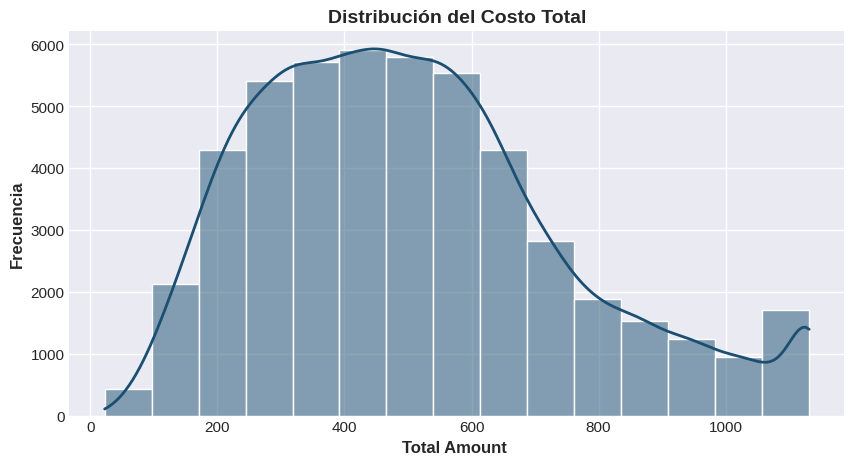

In [147]:
# Histograma de Costo Total de los envios
plt.figure(figsize=(10, 5)) # Ajustar tamaño para este gráfico específico
sns.histplot(data=df, x='Total Amount', bins=15, kde=True)
plt.title('Distribución del Costo Total')
plt.xlabel('Total Amount ')
plt.ylabel('Frecuencia')
plt.show()

El objetivo de esta visualizacion es ver cómo se distribuyen los costos totales (Total Amount) en función de su frecuencia (Count).

**Patrones observables:**

La mayoría de los puntos están concentrados en la parte inferior izquierda (valores bajos de Total Amount y Count), lo que sugiere que:

1) Hay muchos casos con montos totales pequeños

2) Algunos puntos aislados hacia la derecha o arriba indican valores atípicos (outliers):

3) Pocos casos con montos totales altos (ej. cerca de 1400).

Como conclusion podemos decir que la distribución es asimétrica (sesgada hacia la izquierda), común en datos financieros donde la mayoría de los costos son bajos, pero unos pocos son significativamente altos.

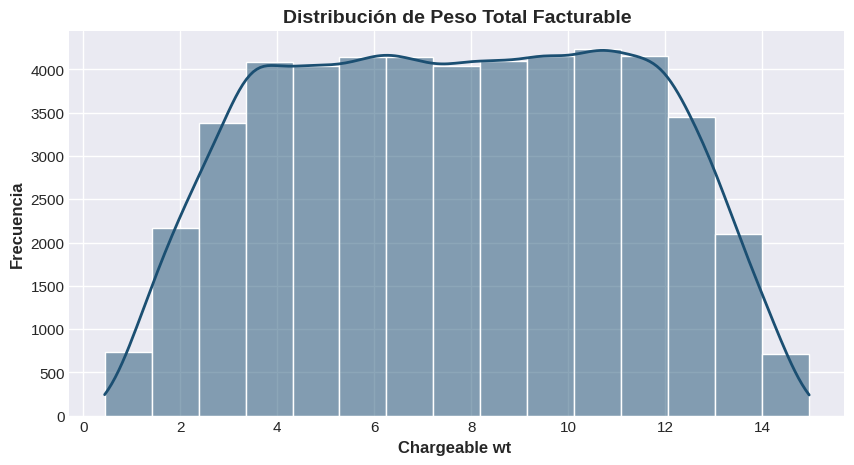

In [148]:
# Histograma de peso total facturable
plt.figure(figsize=(10, 5)) # Ajustar tamaño para este gráfico específico
sns.histplot(data=df, x='Chargeable Wt', bins=15, kde=True)
plt.title('Distribución de Peso Total Facturable')
plt.xlabel('Chargeable wt ')
plt.ylabel('Frecuencia')
plt.show()

Pico principal: Hay una concentración de envíos con peso efectivo entre 6 y 10 kg, donde la densidad es más alta.

Distribución unimodal: La curva tiene un solo pico, lo que indica que la mayoría de los envíos tienen pesos similares.

Cola hacia la derecha: Hay algunos envíos con pesos más altos (hasta 15 kg), pero son menos frecuentes.

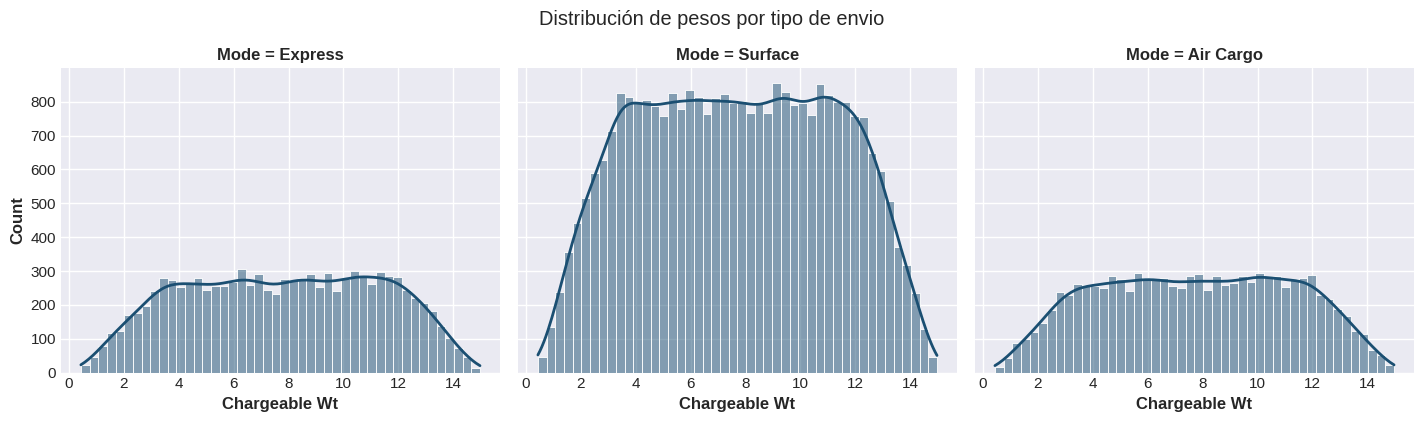

In [149]:
# Displot: Distribución de pesos por tipo de envio
sns.displot(data=df, x='Chargeable Wt', col='Mode', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de pesos por tipo de envio', y=1.05) # Título general ajustado
plt.show()

El medio de envio mas utilizado es Surface, muy pocos envios de menos de 2kg en las tres modalidades, el rango principal en las tres es de 3kg a 12kg.

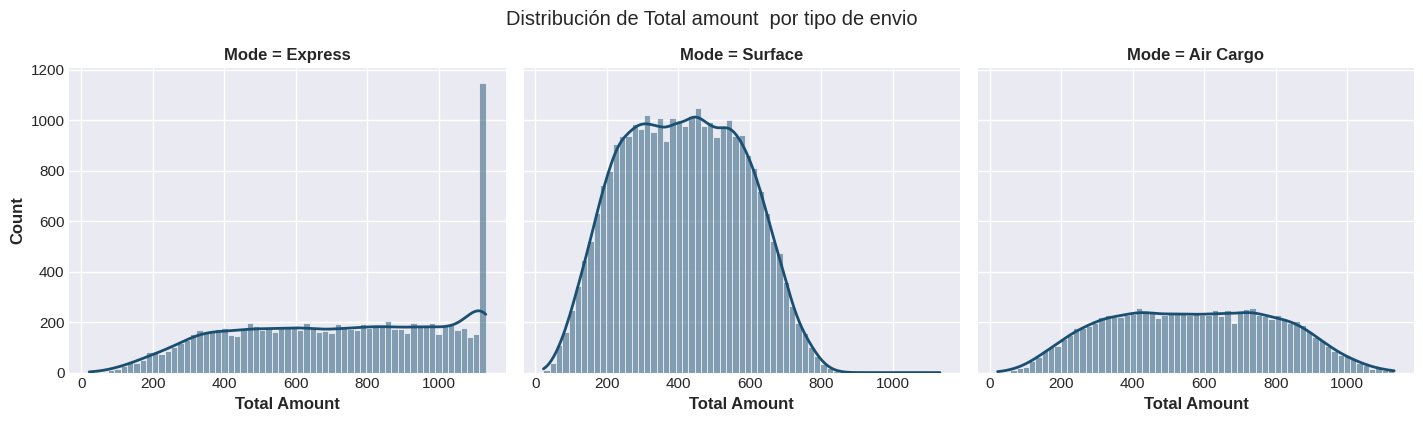

In [150]:
# Displot: Distribución de Total amount por tipo de envio
sns.displot(data=df, x='Total Amount', col='Mode', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Total amount  por tipo de envio', y=1.05) # Título general ajustado
plt.show()

 **Express**

Rango amplio de montos: desde 100  hasta mas de 400.

Distribución relativamente plana entre 300 y 400

Algunos valores más altos (outliers), pero no dominan.

Express parece tener una amplia gama de tarifas, lo cual puede deberse a:

Variación en distancias, tamaños/volúmenes diversos, servicios premium u opcionales.


**Surface**

Pico claro entre 300 y 500, caída brusca a partir de los 600.

Distribución más concentrada que las otras dos modalidades.

Muy pocos envíos con montos > 700.

Surface tiene una estructura de tarifas más estándar y predecible.
Parece ser el método más económico y masivo, posiblemente con rutas y reglas bien definidas.

**Air Cargo**

Rango entre 200 y 1200, con muchos valores entre 400 y 800.

Distribución levemente sesgada a la derecha.

Aunque tiene pocos envíos, sus montos son más elevados en general.

Air Cargo es claramente más caro por envío individual, lo cual es lógico dado  el tipo de servicio. Ideal para envíos urgentes, delicados o internacionales.

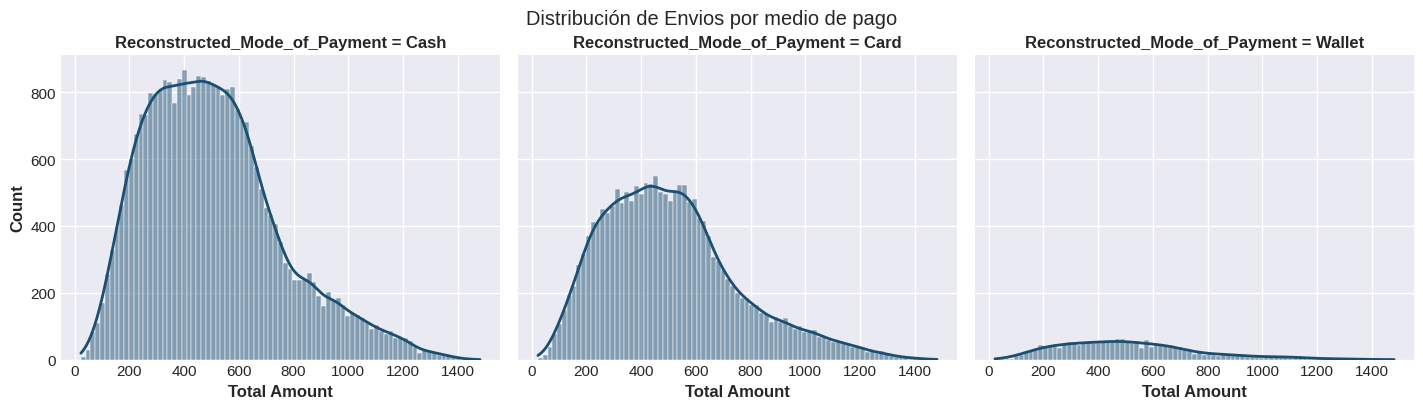

In [159]:
# Reconstruct 'Mode of Payment' from dummy variables for visualization purposes
def get_payment_mode(row):
    if row['Mode of Payment_Cash']:
        return 'Cash'
    elif row['Mode of Payment_Wallet']:
        return 'Wallet'
    else:
        # Assuming 'Card' was the dropped category or default when neither Cash nor Wallet is True
        return 'Card'

# Use df_encoded as it contains the dummy variables
df_encoded['Reconstructed_Mode_of_Payment'] = df_encoded.apply(get_payment_mode, axis=1)

# Displot: Distribución de Envios por medio de pago
sns.displot(data=df_encoded, x='Total Amount', col='Reconstructed_Mode_of_Payment', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Envios por medio de pago', y=1.02) # Título general ajustado
plt.show()

Análisis por medio de pago

**Cash**

Pico de envíos entre 300 y 500.

Distribución sesgada hacia la derecha: hay muchos envíos con valores bajos y pocos con valores altos (> 800).

Es claramente el medio de pago más utilizado, con más de 800 envíos por rango.

El Efectivo domina las operaciones, especialmente en envíos de bajo a mediano valor.

Probablemente se trata de clientes ocasionales, sin integración digital.

**Card**

Distribución parecida a la de efectivo, pero con menor volumen.

Rango más concentrado entre 300 y 600, también con sesgada a a derecha

Es el segundo medio de pago más común.

La tarjeta se utiliza para montos similares al efectivo, pero quizá por un perfil de cliente más digital o para pagos sin manejo de efectivo.

**Wallet**

Mucho menor volumen.

Distribución en un rango similar (300 -600), con muy pocos valores extremos.

La billetera digital todavía tiene poca adopción, aunque su comportamiento es similar a los otros medios.

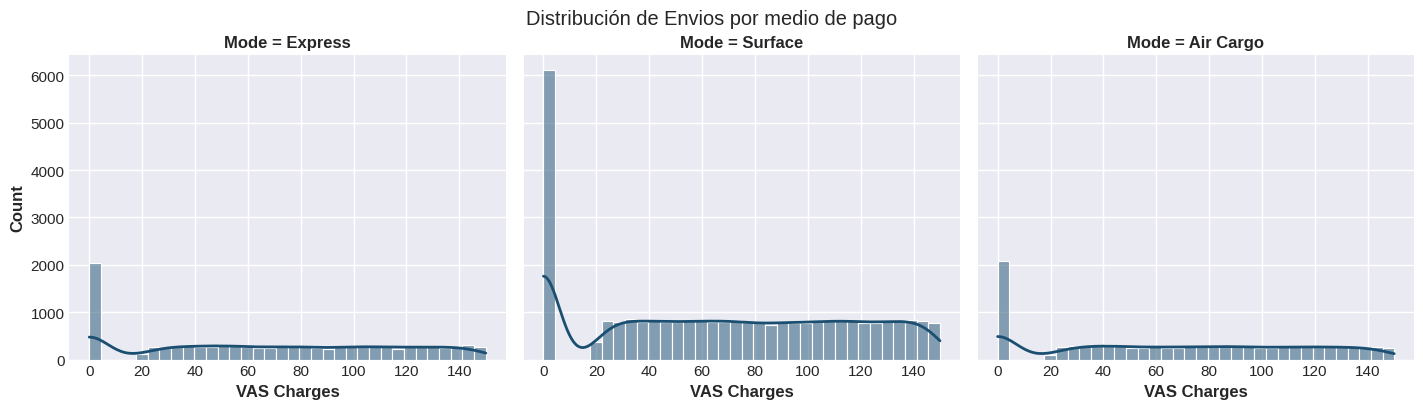

In [160]:
# Displot: Distribución de Envios por medio de pago
sns.displot(data=df, x='VAS Charges', col='Mode', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Envios por medio de pago', y=1.02) # Título general ajustado
plt.show()

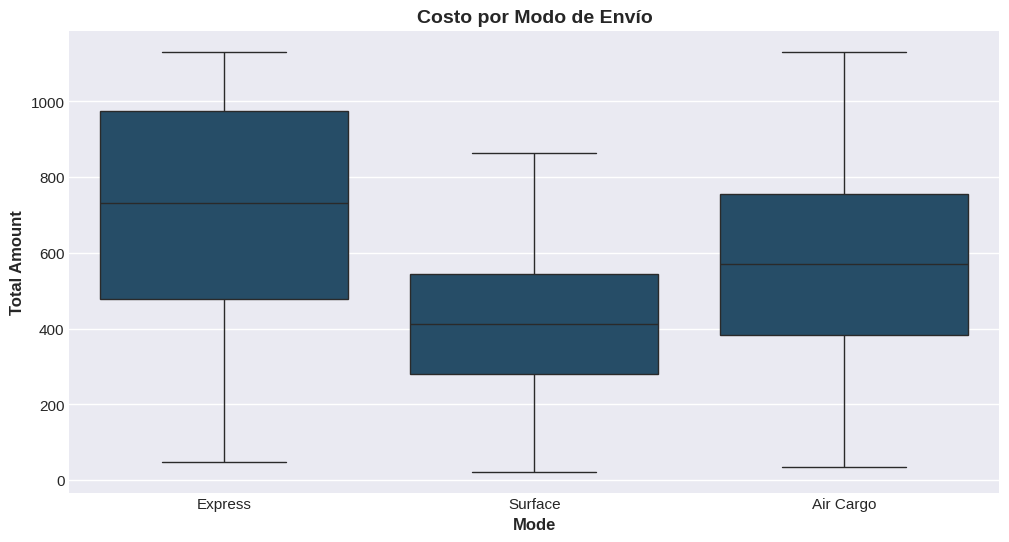

In [161]:
# Boxplot de "Total Amount" por "Mode"
sns.boxplot(x="Mode", y="Total Amount", data=df)
plt.title("Costo por Modo de Envío")
plt.show()

El gráfico de caja (boxplot) muestra la distribución de los costos totales por modo de envío. Los tres modos son: Express, Surface y Air Cargo.

**Express**: es el modo con el rango de costos más amplio, llegando hasta aproximadamente 1400 unidades monetarias. La mediana (línea en medio de la caja) está alrededor de 700-800, lo que indica que la mitad de los costos están por debajo y por encima de ese valor. La caja (intercuartílico) indica que el 50% de los costos oscilan entre aproximadamente 500 y 1000. Los bigotes muestran que hay costos extremos, con algunos valores cercanos a 0 y otros hasta aproximadamente 1400.

**Surface**: es el modo con los costos más bajos en promedio. La mediana está alrededor de 400-500, por lo que la mayoría de los costos son menores comparados con los otros modos. La dispersión (tamaño de la caja) es menor, indicando que los costos están más concentrados en torno a esa media. Los costos extremos varían desde cerca de 0 hasta aproximadamente 800-900.

**Air Cargo**: tiene una dispersión intermedia, con una mediana alrededor de 700. Los costos pueden variar desde aproximadamente 200 hasta 1200. La distribución muestra que, en general, el costo del envío por aire es más alto que el de surface, pero menos que el express en algunos casos.

Express es el modo más costoso y también tiene una mayor variabilidad en los costos. Surface es más económico y más consistente en los costos. Air Cargo tiene costos intermedios y una dispersión considerable.


**Hipótesis 2 (Diferencias por modo)** **RECHAZAR H₀**

Este gráfico proporciona evidencia muy fuerte para rechazar la hipótesis nula:

Las diferencias son visualmente obvias y sustanciales
Express es ~85% más caro que Surface en la mediana
Air Cargo está ~45% más caro que Surface

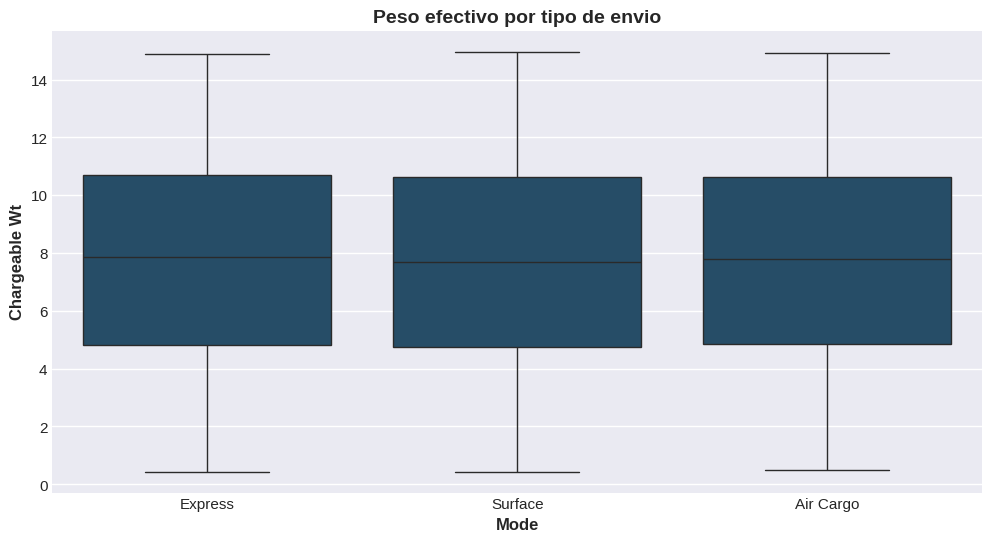

In [162]:
# Boxplot de "Chargeable Wt" por "Mode"
sns.boxplot(x="Mode", y="Chargeable Wt", data=df)
plt.title("Peso efectivo por tipo de envio")
plt.show()

Homogeneidad entre modos: Contrario a lo que podría esperarse, no hay diferencias significativas en el peso de los paquetes según el modo de transporte
Presencia de outliers: Los tres modos muestran valores atípicos superiores (puntos por encima de los bigotes), indicando envíos ocasionales de mayor peso
Concentración en pesos bajos-medios: La mayoría de envíos se concentran en el rango de 2-15 kg aproximadamente.
No se observa presencia de outliers.

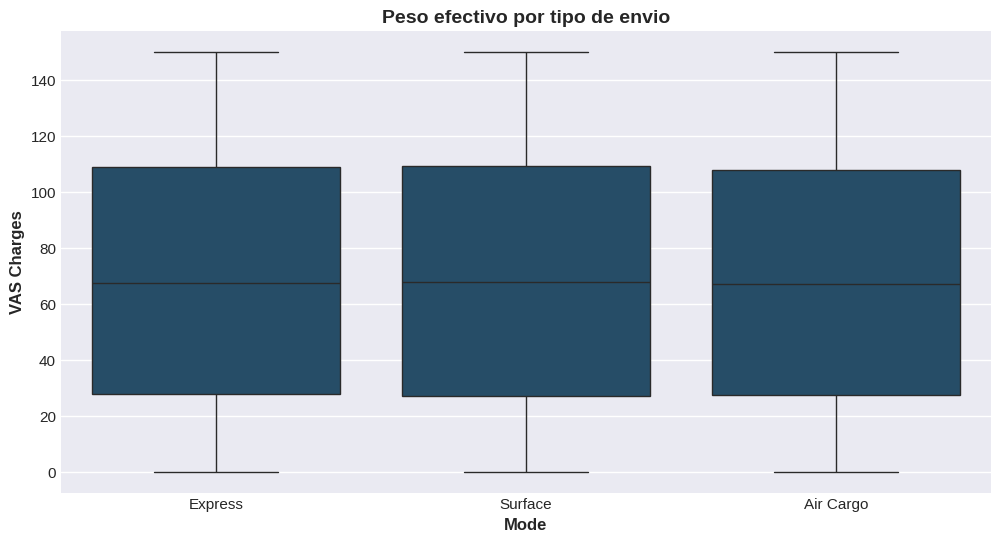

In [163]:
# Boxplot de "Chargeable Wt" por "Mode"
sns.boxplot(x="Mode", y="VAS Charges", data=df)
plt.title("Peso efectivo por tipo de envio")
plt.show()

Distribuciones Similares pero con Diferencias Sutiles:

Medianas prácticamente idénticas: ~67-70 para los tres modos
Rangos intercuartílicos similares: Aproximadamente de 30 a 110
Valores mínimos: Todos cerca de 0 (servicios sin VAS)
Valores máximos: Ligeramente diferentes entre modos


**Para Hipótesis 3 (Cargos adicionales):**
Este gráfico sugiere que probablemente se rechazará H₀, ya que:

Los VAS charges muestran valores sustanciales (no son cero)
Hay variabilidad considerable en los cargos
La mediana ~70 indica que la mayoría de envíos tiene algún cargo adicional

**Para Hipótesis 2 (Diferencias por modo):**
Las distribuciones son muy similares, lo que podría indicar:

Posible no rechazo de H₀ para diferencias por modo en VAS
Los cargos adicionales siguen patrones similares independientemente del modo

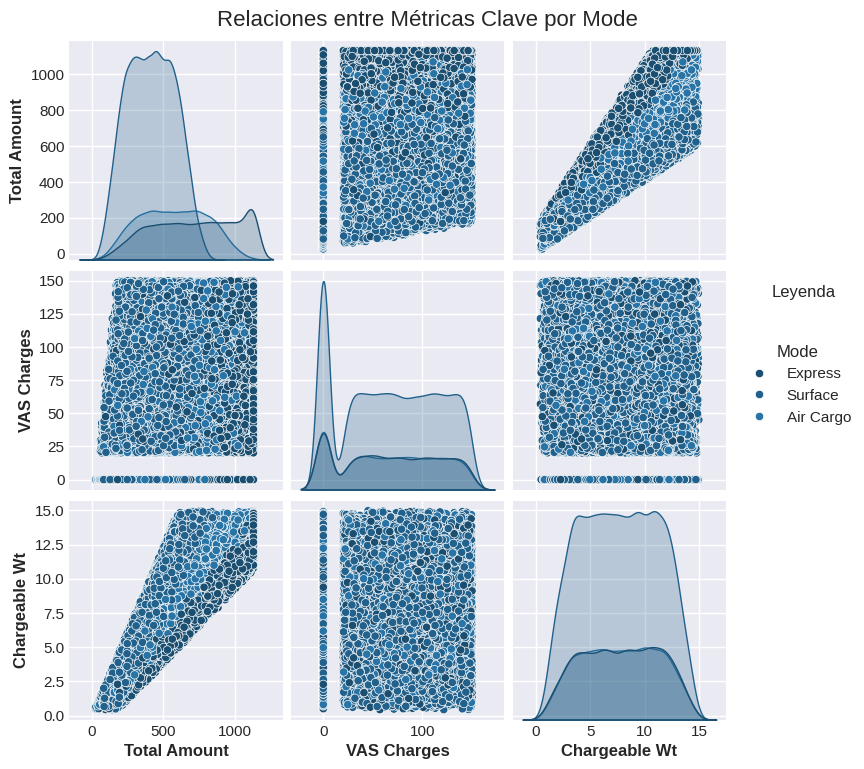

In [156]:
# Pairplot para visión general
columnas_pairplot = ['Total Amount', 'Mode', 'VAS Charges','Chargeable Wt']
sns.pairplot(df[columnas_pairplot], hue='Mode')
plt.legend(title='Leyenda', bbox_to_anchor=(1.15, 2.05), loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.suptitle('Relaciones entre Métricas Clave por Mode', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 1, 1, 1])
plt.show()

Análisis de Relaciones Clave

**Total Amount vs Chargeable Wt (Hipótesis 1)**

Correlación positiva muy fuerte y lineal.
Diferenciación clara por modo: Cada color mantiene su pendiente

**Express (azul):** Pendiente más pronunciada = mayor costo por kg

**Surface (naranja):** Pendiente menor = más económico por kg

**Conclusión:** RECHAZAR H₀ - El peso SÍ tiene efecto significativo


**Total Amount vs VAS Charges (Hipótesis 3)**

Correlación positiva moderada-fuerte

Relación no perfectamente lineal pero consistente

Todos los modos muestran la misma tendencia

**Conclusión:** RECHAZAR H₀ - Los VAS SÍ afectan el total

**Diferencias por Modo (Hipótesis 2)**

Distribuciones en diagonal confirman:

**Express**: Distribución desplazada hacia valores altos (azul)

**Surface**: Concentrada en valores bajos (naranja)

**Air Cargo:** Intermedia (verde)

**Conclusión:** RECHAZAR H₀ - Los modos SÍ difieren significativamente



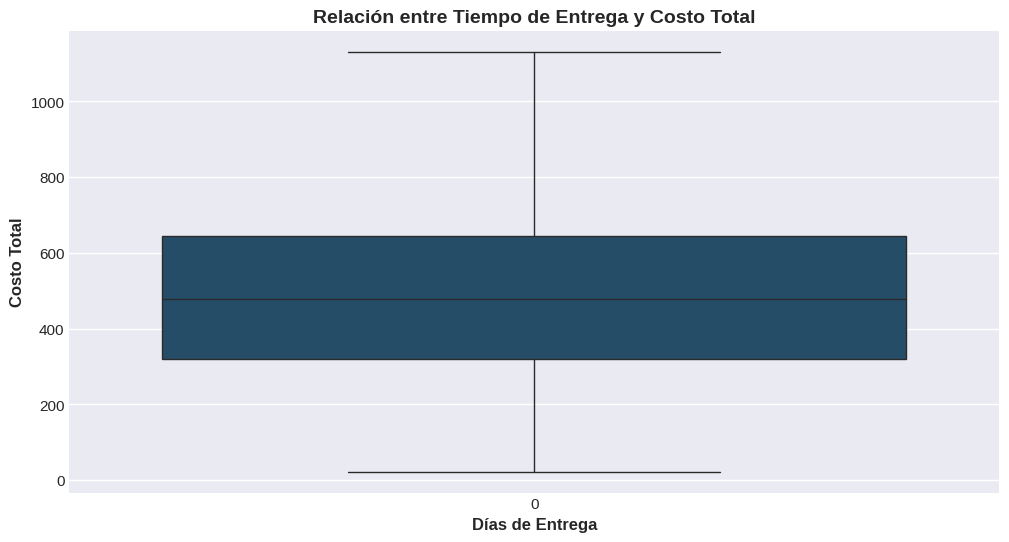

In [164]:
# Boxplot para ver la distribución de costos según los días que tardó
sns.boxplot(x='Delivery_Days', y='Total Amount', data=df)

plt.title('Relación entre Tiempo de Entrega y Costo Total')
plt.xlabel('Días de Entrega')
plt.ylabel('Costo Total')

plt.show()

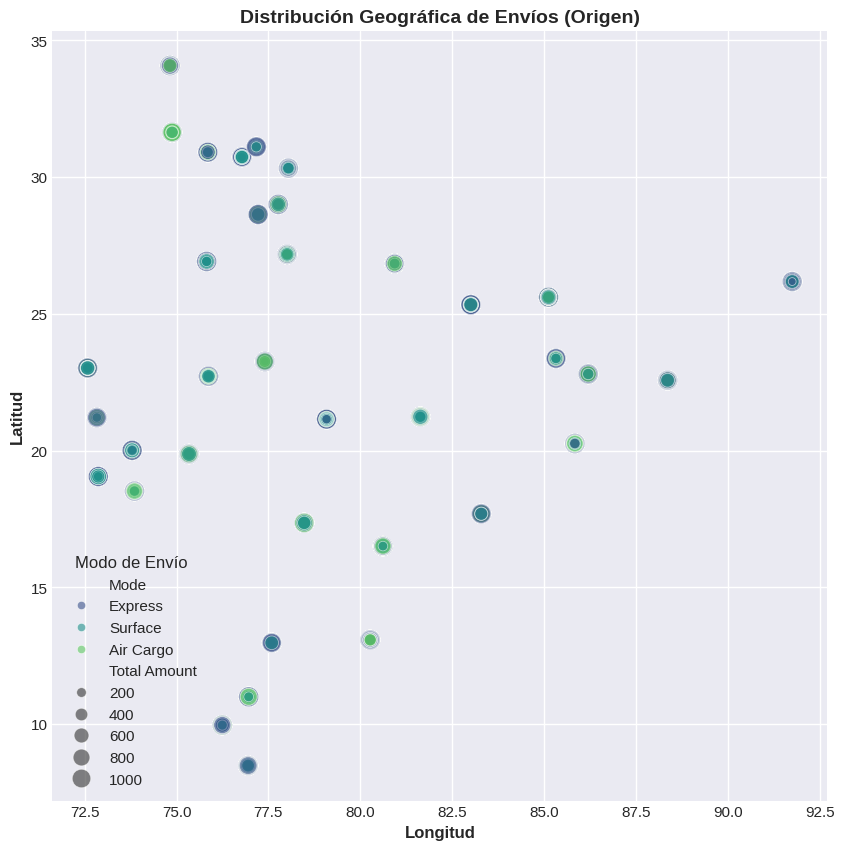

In [166]:
plt.figure(figsize=(10, 10))

# Nota: Asegúrate de haber separado la tupla (Lat, Lon) en columnas antes.
# Si no lo has hecho, usa este pequeño truco antes de graficar:
df['Coords_Origin_Lat'] = df['Coords_Origin'].apply(lambda x: x[0] if isinstance(x, tuple) else None)
df['Coords_Origin_Lon'] = df['Coords_Origin'].apply(lambda x: x[1] if isinstance(x, tuple) else None)

# Usamos las coordenadas de Origen para pintar los puntos
# Hue = Modo de envío (para ver si hay rutas aéreas vs terrestres definidas)
sns.scatterplot(x='Coords_Origin_Lon', y='Coords_Origin_Lat',
                data=df, hue='Mode', size='Total Amount',
                sizes=(20, 200), alpha=0.6, palette='viridis')


plt.title('Distribución Geográfica de Envíos (Origen)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Modo de Envío')
plt.show()

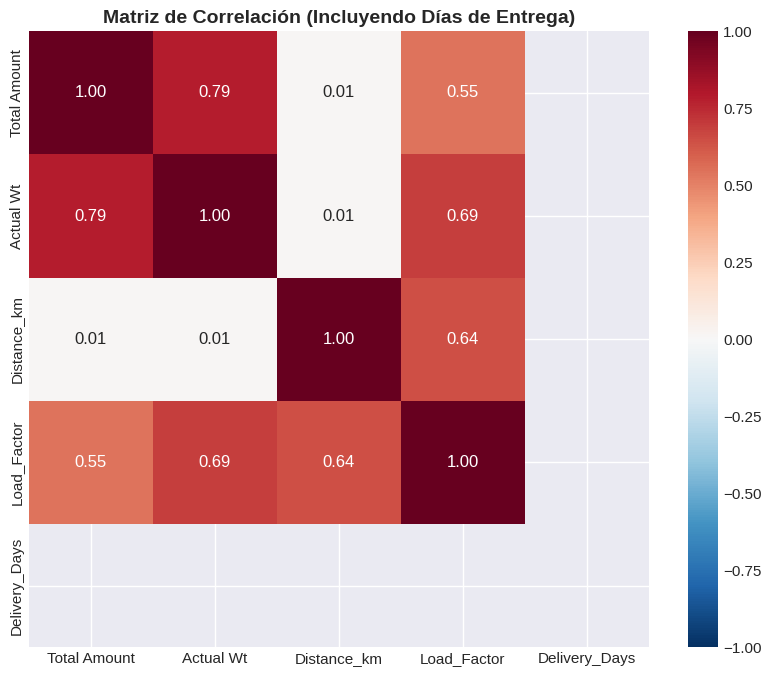

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definimos la lista EXACTA de columnas que queremos analizar
# Agregamos 'Delivery_Days' explícitamente
cols_a_graficar = ['Total Amount', 'Actual Wt', 'Distance_km', 'Load_Factor', 'Delivery_Days']

# 2. Calculamos la correlación solo de estas columnas
corr_matrix_final = df[cols_a_graficar].corr()

# 3. Generamos el Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_final, annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1)

plt.title('Matriz de Correlación (Incluyendo Días de Entrega)')
plt.show()

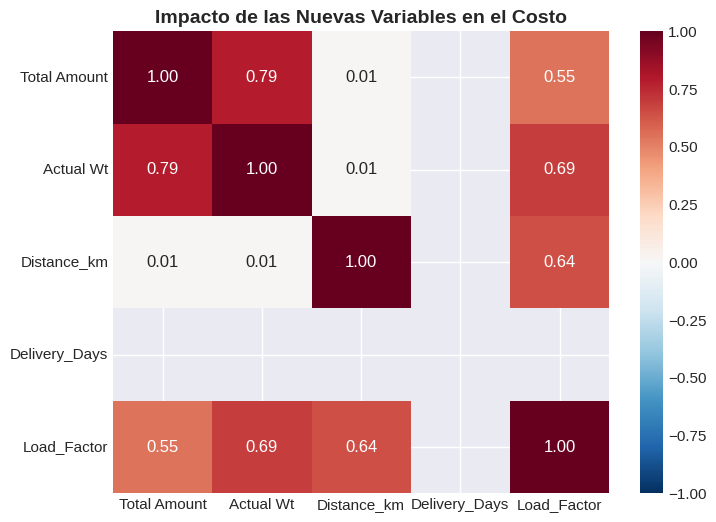

In [168]:
# Seleccionamos las nuevas variables creadas
cols_corr = ['Total Amount', 'Actual Wt', 'Distance_km', 'Delivery_Days', 'Load_Factor']
corr = df[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1)
plt.title('Impacto de las Nuevas Variables en el Costo')
plt.show()

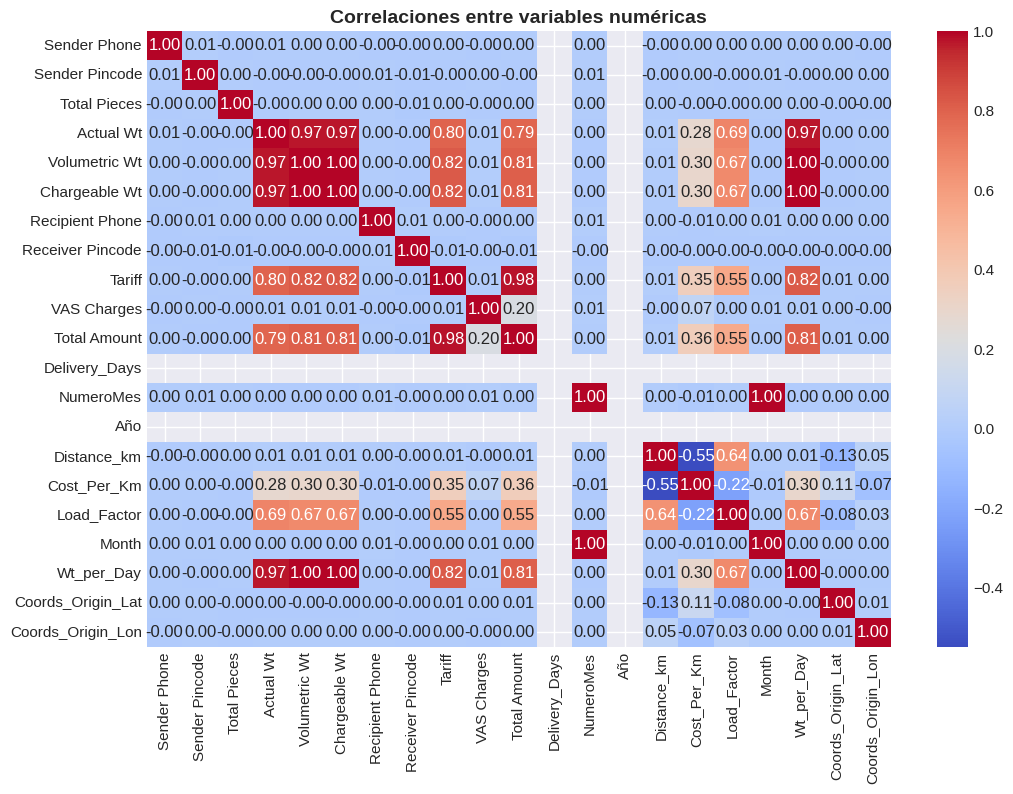

In [169]:
# Mapa de calor de correlaciones
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlaciones entre variables numéricas")
plt.show()

**Hipótesis 1 - Influencia del peso facturable  (RECHAZAR H₀)**

Chargeable Wt ↔ Total Amount: r = 0.81 (correlación muy fuerte)

Actual Wt ↔ Total Amount: r = 0.78

Volumetric Wt ↔ Total Amount: r = 0.81

Conclusión: El peso tiene un efecto muy significativo sobre el costo

**Hipótesis 3 - Cargos adicionales (RECHAZAR H₀)**

VAS Charges ↔ Total Amount: r = 0.20 (correlación débil pero positiva)

Aunque la correlación es baja, SÍ existe relación estadísticamente significativa

Conclusión: Los VAS sí afectan el monto total

**Tariff vs Total Amount:**

r = 0.98 (correlación casi perfecta)

Esto sugiere que Tariff es el componente principal del Total Amount

VAS son adicionales sobre la tarifa base

**Variables Independientes:**

**Total Pieces:** Correlaciones cercanas a 0 con todo

**Phone numbers y Pincodes:** No correlacionados (como esperado)

 **Variables a incluir:**

Total Amount ~ Chargeable Wt + Mode + VAS Charges + Mode:Chargeable Wt

**Variables a excluir (multicolinealidad):**

 Actual Wt y Volumetric Wt (usar solo Chargeable Wt)

Tariff (r=0.98 con Total Amount - casi la misma variable)

# Preprocesamiento final

In [170]:
# Listar de columnas categóricas a transformar
categorical_cols = ['Nature of Consignment', 'Mode of Payment']

# Crear dummies con drop_first=True para evitar multicolinealidad
dummies = pd.get_dummies(df[categorical_cols], drop_first=True)

# Concatenar los dummies al DataFrame original
df_transformed = pd.concat([df, dummies], axis=1)

dummies.index = df.index ## nos aseguramos que las columnas  del 'dummies' tengan el mismo índice del DataFrame

In [171]:
df = pd.concat([df, dummies], axis=1)## para añadir las nuevas columnas al DataFrame manteniendo las originales

In [172]:
#df.drop('Mode', axis=1, inplace=True) ## luego eliminamos la columna original de 'Mode'

 #Eliminar las columnas originales categóricas
df.drop(columns=categorical_cols, inplace=True)

In [173]:
# Crear variables dummy para Mode
df_encoded = pd.get_dummies(df, columns=['Mode'], prefix='Mode', drop_first=False)
print(f"\n🔧 Variables después de encoding: {list(df_encoded.columns)}")


🔧 Variables después de encoding: ['Origin', 'Destination', 'Date', "Sender's Name", 'Sender Phone', 'Sender Address', 'Sender City', 'Sender State', 'Sender Pincode', 'Total Pieces', 'Actual Wt', 'Volumetric Wt', 'Chargeable Wt', 'Paperwork', 'Sender Signature', 'Sender Date', 'Recipient Name', 'Recipient Phone', 'Recipient Address', 'Recipient City', 'Receiver State', 'Receiver Pincode', 'Description', 'Value Added Services', 'Expiry Date', 'Booking Code', 'Receiver Name', 'Relationship', 'Receive Date', 'Tariff', 'VAS Charges', 'Total Amount', 'Risk Surcharge', 'Delivery_Days', 'NumeroMes', 'Año', 'Coords_Origin', 'Coords_Dest', 'Distance_km', 'Cost_Per_Km', 'Load_Factor', 'Month', 'Is_Weekend', 'SLA_Flag', 'Wt_per_Day', 'Coords_Origin_Lat', 'Coords_Origin_Lon', 'Nature of Consignment_Non-Dox', 'Mode of Payment_Cash', 'Mode of Payment_Wallet', 'Mode_Air Cargo', 'Mode_Express', 'Mode_Surface']


In [174]:
# Crear términos de interacción Mode:Chargeable Wt
df_encoded['Mode_Express_Weight'] = df_encoded['Mode_Express'] * df_encoded['Chargeable Wt']
df_encoded['Mode_Surface_Weight'] = df_encoded['Mode_Surface'] * df_encoded['Chargeable Wt']
df_encoded['Mode_Air Cargo_Weight'] = df_encoded['Mode_Air Cargo'] * df_encoded['Chargeable Wt']

## **Transformamos la variable Objetivo**

 TRANSFORMACIÓN LOGARÍTMICA DE LA VARIABLE OBJETIVO
Total Amount original - Min: 22.63, Max: 1131.42
Log Total Amount - Min: 3.16, Max: 7.03


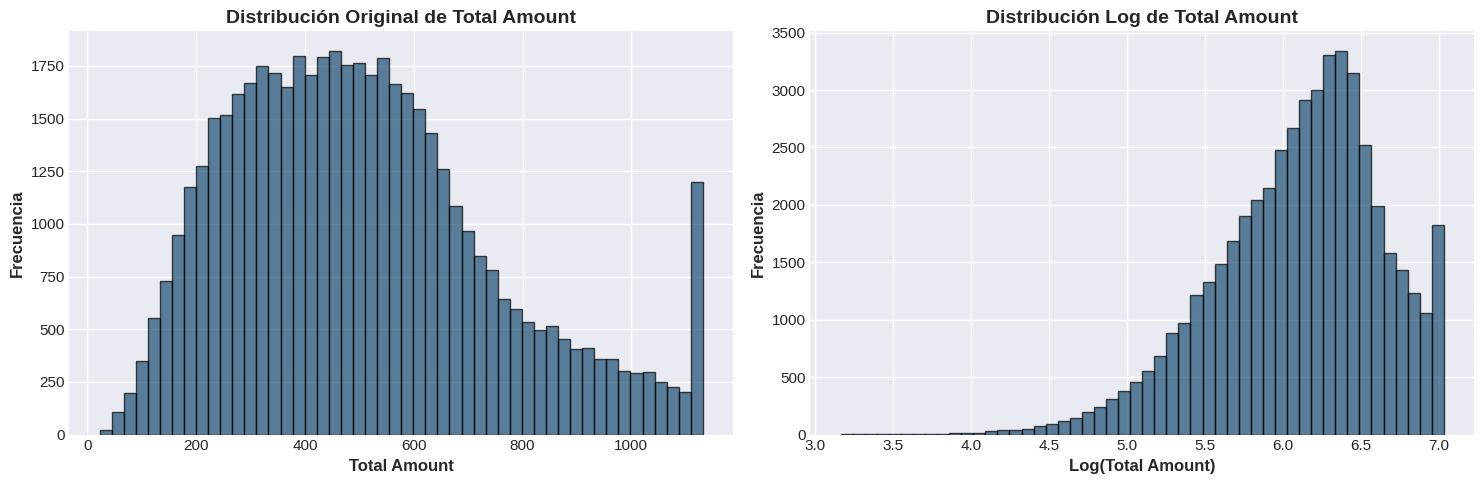

In [175]:
# Transformación logarítmica de la variable objetivo
print(" TRANSFORMACIÓN LOGARÍTMICA DE LA VARIABLE OBJETIVO")
print("="*50)

# Crear log de Total Amount (agregamos 1 para evitar problemas con valores 0)
df['log_total_amount'] = np.log(df['Total Amount'] + 1)

print(f"Total Amount original - Min: {df['Total Amount'].min():.2f}, Max: {df['Total Amount'].max():.2f}")
print(f"Log Total Amount - Min: {df['log_total_amount'].min():.2f}, Max: {df['log_total_amount'].max():.2f}")

# Visualizar la transformación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Distribución original
ax1.hist(df['Total Amount'], bins=50, alpha=0.7,edgecolor='black')
ax1.set_title('Distribución Original de Total Amount')
ax1.set_xlabel('Total Amount')
ax1.set_ylabel('Frecuencia')

# Distribución logarítmica
ax2.hist(df['log_total_amount'], bins=50, alpha=0.7, edgecolor='black')
ax2.set_title('Distribución Log de Total Amount')
ax2.set_xlabel('Log(Total Amount)')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# ** Análisis de las Distribuciones**

# **Gráfico Izquierdo - Distribución Original:**

Forma: distribución sesgada hacia la derecha (cola larga hacia valores altos)

Problema: la mayoría de valores se concentran entre 0-600, pero hay una cola extendida hasta 1400

Interpretación: pocos envíos muy costosos y muchos envíos de costo moderado
Rango: 22.63 a 1481.16

# **Gráfico Derecho - Distribución Log Transformada:**

Forma: Distribución mucho más simétrica y normal

Beneficio: Los datos ahora siguen una distribución más parecida a la normal

Interpretación: La transformación "comprime" los valores altos y "expande" los bajos

Rango: 3.16 a 7.30 (en escala logarítmica)

La distribución logarítmica se ve casi perfectamente normal, lo cual es ideal para el análisis de regresión a realizar.